In [1]:
# Установка всего необходимого
!pip install ddgs ftfy faiss-cpu

Архитектура проекта

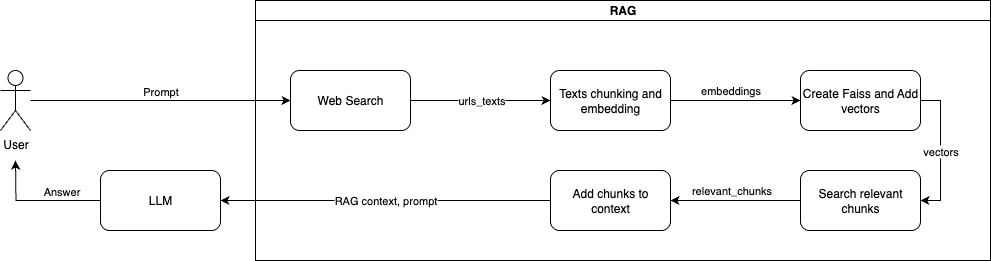

In [2]:
from ddgs import DDGS
import requests
from bs4 import BeautifulSoup
from typing import List
import time
import random
import ftfy
import re
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# Функции

## Web Search

### Парсинг и обработка данных

In [3]:
def text_cleanup(text):
    """
    Усиленная очистка текста от всего лишнего с фокусом на контекст для LLM
    """
    if not text or not isinstance(text, str):
        return ""

    # 0. Предварительная очистка от очевидного мусора
    import re

    # Удаляем типичные рекламные блоки и меню
    ad_patterns = [
        # Рекламные фразы и акции
        r'скидк[аиуей]\s*\d+%?',
        r'акци[ияей]\s*\d+%?',
        r'программ[ауы]\s*лояльност',
        r'бонус\s*\d+',
        r'подарк[ауи]',
        r'распродаж',

        # Навигационные элементы
        r'меню',
        r'каталог',
        r'где\s*купить',
        r'доставк[ауи]',
        r'сервис',
        r'поддержк[ауи]',
        r'контакт[ыау]',
        r'новости',
        r'блог',
        r'ваканси[ии]',
        r'партнерам',

        # Технические элементы сайтов
        r'сравнени[ея]\s*\d+',
        r'чат\s*поддержки',
        r'обратная\s*связь',
        r'конкурс[ыау]',
        r'соцсет[ией]\s*компании',
        r'f\.?\s*q\.?',
        r'faq',

        # Даты и временные метки
        r'\d{1,2}\s+\w+\s+\d{4}',
        r'\d{1,2}\.\d{1,2}\.\d{4}',
        r'\d{4}-\d{2}-\d{2}',

        # Хлебные крошки и пути
        r'главная\s*>\s*\w+\s*>\s*\w+',
        r'home\s*>\s*\w+\s*>\s*\w+',
    ]

    for pattern in ad_patterns:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)

    # 1. Базовые исправления кодировки
    try:
        import ftfy
        text = ftfy.fix_text(text)
    except:
        pass

    # 2. Удаление URL и ссылок (более агрессивно)
    text = re.sub(r'https?://[^\s]+', '', text)
    text = re.sub(r'www\.[^\s]+', '', text)
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)  # Markdown ссылки

    # 3. Удаление специфических артефактов веб-страниц
    web_artifacts = [
        r'<[^>]+>',  # HTML теги
        r'&[a-z]+;',  # HTML entities
        r'<!--.*?-->',  # HTML комментарии
        r'{%[^%]+%}',  # Шаблонные теги
        r'{{[^}]+}}',  # Шаблонные переменные
        r'@\w+',  # Упоминания
        r'#\w+',  # Хештеги
        r'\bID:\s*\d+\b',  # ID
        r'\bISBN[:\s]+\S+',  # ISBN
        r'\bISSN[:\s]+\S+',  # ISSN
    ]

    for pattern in web_artifacts:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)

    # 4. Удаление номеров телефонов и подобного
    text = re.sub(r'[\+\(]?[1-9][0-9 .\-\(\)]{8,}[0-9]', '', text)

    # 5. Удаление слишком длинных последовательностей заглавных букв (обычно это аббревиатуры или коды)
    text = re.sub(r'\b[A-ZА-Я]{4,}\b', '', text)

    # 6. Удаление "мусорных" последовательностей
    text = re.sub(r'\b(?:\w*[0-9]+\w*){3,}\b', '', text)  # Слишком много цифр в слове
    text = re.sub(r'\b\w*[xX]\w*\b', '', text)  # Слова с "x" (часто размеры)
    text = re.sub(r'\b\d+[xX]\d+\b', '', text)  # Размеры типа 1920x1080

    # 7. Оригинальная очистка символов (из вашей функции)
    allowed_chars = {
        'а', 'б', 'в', 'г', 'д', 'е', 'ё', 'ж', 'з', 'и', 'й', 'к', 'л', 'м',
        'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ', 'ъ',
        'ы', 'ь', 'э', 'ю', 'я',
        'А', 'Б', 'В', 'Г', 'Д', 'Е', 'Ё', 'Ж', 'З', 'И', 'Й', 'К', 'Л', 'М',
        'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ъ',
        'Ы', 'Ь', 'Э', 'Ю', 'Я',
        'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm',
        'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z',
        'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
        'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
        '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
        ' ', '\t', '\n', '\r',
        '.', ',', '!', '?', ';', ':', '-', '–', '—', '"', "'", '«', '»',
        '(', ')', '[', ']', '{', '}', '<', '>',
        '@', '#', '$', '%', '&', '*', '+', '=', '/', '\\', '|',
        '№', '°', '℃', '℉', '₽', '$', '€', '£', '¥',
    }

    cleaned_text = []
    for char in text:
        if char in allowed_chars:
            cleaned_text.append(char)
        else:
            cleaned_text.append(' ')
    text = ''.join(cleaned_text)

    # 8. Удаление непечатаемых символов
    text = ''.join(char for char in text if char.isprintable() or char in ['\n', '\t', '\r'])

    # 9. Фильтрация по релевантности (для контекста LLM)
    # Если текст содержит технические описания товаров, оставляем только их
    sentences = re.split(r'[.!?]+', text)
    relevant_sentences = []

    # Ключевые слова, указывающие на полезную информацию
    positive_keywords = [
        'робот', 'пылесос', 'уборк', 'выбор', 'тип', 'мощность',
        'площад', 'заряд', 'батаре', 'навигац', 'функц',
        'характеристик', 'параметр', 'рекомендац', 'совет',
        'преимуществ', 'недостатк', 'сравнен', 'отлич'
    ]

    # Слова, указывающие на мусор
    negative_keywords = [
        'купить', 'цена', 'стоимость', 'заказ', 'корзин',
        'доставк', 'оплат', 'магазин', 'интернет', 'онлайн',
        'акци', 'скидк', 'распродаж', 'бонус', 'подарок'
    ]

    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence or len(sentence.split()) < 3:
            continue

        sentence_lower = sentence.lower()

        # Проверяем релевантность
        has_positive = any(keyword in sentence_lower for keyword in positive_keywords)
        has_negative = any(keyword in sentence_lower for keyword in negative_keywords)

        # Если есть положительные ключевые слова и мало отрицательных
        if has_positive and not has_negative:
            relevant_sentences.append(sentence)
        # Если нет явного мусора и предложение достаточно содержательное
        elif not has_negative and len(sentence.split()) > 5:
            # Проверяем разнообразие слов (избегаем повторений)
            words = sentence.split()
            unique_words = len(set(words))
            if unique_words / len(words) > 0.6:  # Более 60% уникальных слов
                relevant_sentences.append(sentence)

    text = '. '.join(relevant_sentences)

    # 10. Удаление повторяющихся фраз и предложений
    sentences = text.split('. ')
    if sentences:
        unique_sentences = []
        seen_phrases = set()

        for sentence in sentences:
            sentence = sentence.strip()
            if not sentence:
                continue

            # Нормализуем для сравнения
            normalized = ' '.join(sorted(set(sentence.lower().split()[:10])))

            # Если не видели подобную фразу
            if normalized not in seen_phrases:
                unique_sentences.append(sentence)
                seen_phrases.add(normalized)

        text = '. '.join(unique_sentences)

    # 11. Оригинальные шаги нормализации (из вашей функции)
    lines = (line.strip() for line in text.splitlines())
    chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
    text = '\n'.join(chunk for chunk in chunks if chunk)

    # 12. Нормализация пробелов
    text = re.sub(r'\s+', ' ', text)

    # 13. Удаление одиночных символов
    words = text.split()
    single_chars_to_keep = {'a', 'и', 'в', 'с', 'у', 'о', 'я', 'A', 'I', 'a', 'i'}
    cleaned_words = []

    for word in words:
        if len(word) > 1 or word in single_chars_to_keep:
            cleaned_words.append(word)
        elif word.isdigit():
            cleaned_words.append(word)

    text = ' '.join(cleaned_words)

    # 14. Удаление повторяющихся слов подряд
    words = text.split()
    if words:
        deduplicated = [words[0]]
        for i in range(1, len(words)):
            if words[i] != words[i-1]:
                deduplicated.append(words[i])
        text = ' '.join(deduplicated)

    # 15. Финальная нормализация пунктуации
    text = re.sub(r'\s+([.,!?;:])', r'\1', text)
    text = re.sub(r'([.,!?;:])\s+', r'\1 ', text)
    text = re.sub(r'\(\s+', '(', text)
    text = re.sub(r'\s+\)', ')', text)
    text = re.sub(r'«\s+', '«', text)
    text = re.sub(r'\s+»', '»', text)

    # 16. Удаление пустых скобок и кавычек
    text = re.sub(r'\(\s*\)', '', text)
    text = re.sub(r'\[\s*\]', '', text)
    text = re.sub(r'\{\s*\}', '', text)
    text = re.sub(r'«\s*»', '', text)
    text = re.sub(r'"\s*"', '', text)
    text = re.sub(r"'\s*'", '', text)

    # 17. Финальная очистка пробелов
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [4]:
def get_text_from_url(url):

    session = requests.Session()
    # Полный набор заголовков, имитирующих браузер
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
        'Accept-Language': 'ru-RU,ru;q=0.9,en-US;q=0.8,en;q=0.7',
        'Accept-Encoding': 'gzip, deflate, br',
        'Connection': 'keep-alive',
        'Upgrade-Insecure-Requests': '1',
        'Sec-Fetch-Dest': 'document',
        'Sec-Fetch-Mode': 'navigate',
        'Sec-Fetch-Site': 'none',
        'Sec-Fetch-User': '?1',
        'Cache-Control': 'max-age=0',
        'DNT': '1',
    }
    session.headers.update(headers)
    try:
        # Отправляем GET-запрос
        response = session.get(url)
        response.raise_for_status()  # Проверяем успешность запроса

        # Создаем объект BeautifulSoup
        soup = BeautifulSoup(response.text, 'html.parser')

        # Удаляем скрипты и стили
        for script in soup(["script", "style", "nav", "footer", "header"]):
            script.decompose()

        # Получаем весь текст
        text = soup.get_text(separator=' ', strip=True)

        # Убираем лишние пробелы и переносы
        text = text_cleanup(text)

        return text[1000:] # Пропустим 1000 символов, так как это чаще всего ненужная информация

    except requests.RequestException as e:
        print(f"Ошибка при запросе: {e}")
        return None

### DDGS search

In [5]:
def web_search(prompt, max_search_results=10):
  results = DDGS().text(prompt, max_results=max_search_results, region='ru-ru', backend='yandex')
  texts = []
  for site in results:
    url = site['href']
    texts.append({
        'url': url,
        'text': get_text_from_url(url)})
  if texts:
      texts = [text for text in texts if text['text']]
      print(len(texts))
      return texts
  else:
      print('Внешние источники информации не найдены')

## Texts chunking and embedding

### Разбиение текста на чанки

In [6]:
def split_text_into_chunks(text: str, chunk_size: int = 500, overlap: int = 100) -> List[str]:
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)
        start += chunk_size - overlap
    return chunks

### Создание Embeddings

In [7]:
def create_embeddings(sites):
    embeddings = []
    texts = [site['text'] for site in sites]
    vectors = embedding_model.encode(texts)
    for i, site in enumerate(sites):
        if 'text' in site and site['text'].strip():
            embeddings.append({
                "text": site['text'],
                "vector": vectors[i]
            })
    return embeddings

In [8]:
def embedding_pipeline(urls_texts, chunk_size, overlap):
  texts_chunked = [
    {'url': url_text['url'],
     'text': chunk}
    for url_text in urls_texts
    for chunk in split_text_into_chunks(url_text['text'], chunk_size, overlap)
    if chunk.strip()
  ]
  embeddings = create_embeddings(texts_chunked)
  return embeddings


## Create Faiss and Add vectors

In [9]:
def create_vectors(embeddings):
  # Преобразование векторов в NumPy
  vectors = [emb['vector'] for emb in embeddings]
  vectors = np.array(vectors).astype('float32')
  texts = [emb['text'] for emb in embeddings]

  # Создание индекса FAISS
  index = faiss.IndexFlatL2(vectors.shape[1])  # L2 норма
  index.add(vectors)

  return index, texts


## Search relevant chunks

In [10]:
def search_relevant_chunks(query, index, texts, top_k=3):
    query_vector = embedding_model.encode([query])[0].astype('float32')
    query_vector = np.expand_dims(query_vector, axis=0)

    distances, indices = index.search(query_vector, top_k)
    relevant_chunks = [texts[i] for i in indices[0]]
    return relevant_chunks


## Add chunks to context and LLM answer

In [21]:
def generate_answer(query, relevant_chunks, max_context_size):
    if not relevant_chunks:
        return "Не удалось найти релевантные фрагменты.", 0.0

    context = " ".join(relevant_chunks)[:max_context_size]
    if not context.strip():
        return "Контекст пуст. Невозможно сгенерировать ответ.", 0.0

    system_prompt = """Ты эксперт по электронике. Дай конкретный ответ на русском языке.
Используй только информацию из контекста. Будь кратким - 3-5 предложений.
Формат: простой текст без разметки."""

    input_text = f"{system_prompt}\nВопрос: {query}\nКонтекст: {context}\nAnswer:"

    # Генерация ответа
    generated_output = qa_pipeline(input_text)[0]['generated_text']

    answer = generated_output

    return answer

# Основной pipeline

In [12]:
def system_pipline(max_search_results, chunk_size, overlap, top_k, max_context_size):
  # Ввод пользователя
  user_input = input("Введите ваш вопрос (или 'exit' для выхода): ")
  if user_input.lower() == 'exit':
      return

  #Web search
  urls_texts = web_search(user_input, max_search_results=max_search_results)

  embeddings = embedding_pipeline(urls_texts, chunk_size, overlap)
  index, texts = create_vectors(embeddings)

  relevant_chunks = search_relevant_chunks(user_input, index, texts, top_k)

  answer = generate_answer(user_input, relevant_chunks, max_context_size)

  return answer

## Загрузка моделей

In [13]:
embedding_model = SentenceTransformer('intfloat/multilingual-e5-large')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
# Название модели
model_name = "Qwen/Qwen3-1.7B"  # Или другая модель на ваше усмотрение

# Загрузка токенизатора и модели
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype="auto"  # Автоматически выбирает подходящий dtype (float16/bfloat16/float32)
)

# Настройка паддинг-токена (если не установлен)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Создание пайплайна для генерации текста
qa_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    temperature=0.1,
    top_p=0.5,
    repetition_penalty=1.2,
    do_sample=False,
    max_new_tokens=256,
    max_length = None,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
)

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


## Запуск системы

In [29]:
answer = system_pipline(max_search_results=15, chunk_size=1500, overlap=100, top_k=3, max_context_size=4500)
print(answer)

Введите ваш вопрос (или 'exit' для выхода): Как выбрать робот пылесос
Ошибка при запросе: 401 Client Error: Unauthorized for url: https://club.dns-shop.ru/blog/t-172-robotyi-pyilesosyi/90517-kak-vyibrat-robot-pyilesos/
Ошибка при запросе: 429 Client Error: Too Many Requests for url: https://journal.citilink.ru/articles/kak-vybrat-luchshij-robot-pylesos-dlya-doma/
Ошибка при запросе: 403 Client Error: Forbidden for url: https://market.yandex.ru/journal/delegiruem-uborku-robotupylesosu-rasskazyvaem-kak-vybrat-luchshiy
6
Ты эксперт по электронике. Дай конкретный ответ на русском языке.
Используй только информацию из контекста. Будь кратким - 3-5 предложений.
Формат: простой текст без разметки.
Вопрос: Как выбрать робот пылесос
Контекст: ешенный выбор и найти робот-пылесос, который станет вашим надежным помощником в поддержании чистоты и порядка в квартире или доме. Основные параметры при выборе робота-пылесоса Подбирая робот-пылесос, обратите внимание на его ключевые характеристики. Они н

## Пост обработка ответа LLM

In [28]:
def extract_ai_response(full_text):
    """
    Извлекает ответ нейросети из полного текста.
    Ожидает, что ответ начинается с метки 'Answer:' и продолжается до конца текста
    или до следующей явной метки (например, 'Example:').
    """
    # Ищем начало ответа
    answer_start = full_text.find('Answer:')

    if answer_start == -1:
        return None  # Метка 'Answer:' не найдена

    # Находим начало текста ответа (после 'Answer:')
    answer_text_start = answer_start + len('Answer:')

    # Выделяем весь текст после метки
    potential_answer = full_text[answer_text_start:].strip()

    # Если есть другой заголовок после ответа (например, 'Example:'), обрезаем по нему
    example_start = potential_answer.find('**Пример:**')
    if example_start != -1:
        potential_answer = potential_answer[:example_start].strip()

    # Также обрежем по любым двойным переносам строки как возможному разделителю
    double_newline = potential_answer.find('\n\n')
    if double_newline != -1:
        potential_answer = potential_answer[:double_newline].strip()

    return potential_answer

In [30]:
edit_answer = extract_ai_response(answer)
print(edit_answer)

Выберите робот-пылесос, соответствующий потребностям дома. Убедитесь, что он имеет достаточную мощность всасывания (ПА) для уборки ковров или с животными. Выбирайте модели с автономностью от 45–60 минут и возможностью автоматического возврата на зарядку. Уточните тип уборки — сухой или влажной — и проверьте наличие функции уборки по расписанию. Также обратите внимание на сенсоры навигации и датчики высоты для безопасности в больших помещениях.
